## 1D example: induced fourier features

In [1]:
import sys
import os
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), '..')))
import random
from sched import scheduler

import torch
import torch.nn as nn
import torch.nn.functional as F
import gpytorch
import numpy as np
import matplotlib.pyplot as plt

### Data generation

Generated the 1D regression dataset from a GP with RBF kernel. Divide the dataset into two parts: train set (ID) and test set (OOD).

In [2]:
# Base GP model
class GP(gpytorch.models.ExactGP):
    def __init__(self, x_train, y_train):
        super().__init__(x_train, y_train, gpytorch.likelihoods.GaussianLikelihood())
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(
            gpytorch.kernels.RBFKernel()
        )

    def forward(self, x):
        function_mean = self.mean_module(x)
        function_covar = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(function_mean, function_covar)

# Sampling function
def f(x):
    gp = GP(x, torch.randn(len(x)))
    gp.covar_module.outputscale = 1.0
    gp.covar_module.base_kernel.lengthscale = 0.5
    gp.likelihood.noise = 0.2
    with torch.no_grad():
        targets_dist = gp.likelihood(gp(x))
    return targets_dist.rsample(), gp

# Build input data, initialize the GP, and sample from it
random.seed(0)
np.random.seed(0)
torch.manual_seed(0)

x = torch.linspace(-5, 5, 500)
y, gp = f(x)

train_mask = (x > -3) & (x < 3)
to_false = torch.randperm(len(x))[:(train_mask.sum() * 0.5).int()]
train_mask[to_false] = False

x_train = x[train_mask].reshape(-1, 1)
y_train = y[train_mask]
x_test = x[~train_mask].reshape(-1, 1)
y_test = y[~train_mask]

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
print(f'Training points: {x_train.shape[0]}, Test points: {x_test.shape[0]}')

Using device: cpu
Training points: 208, Test points: 292


In [3]:
def plot_confidence_region(y_data, y_mean, y_lower, y_upper, fig_path=None):
    fig, ax = plt.subplots(figsize=[4, 3])
    ax.plot(x_train, y_data, '.', color='k', label='training points')
    ax.plot(x_test, y_mean, color='r', linewidth=1, label='posterior mean')
    ax.fill_between(x_test.squeeze(), y_lower, y_upper, color='r', alpha=0.12)
    ax.set_xticks([])
    ax.set_yticks([-2.5, 0, 2.5])
    # ax.set_xlabel('$x$')
    # ax.set_ylabel('$y$')
    ax.set_title('Mean posterior with 95% confidence', size=10, style='italic')
    ax.legend(fontsize=8)
    fig.tight_layout()
    if fig_path is not None:
        fig.savefig(fig_path, dpi=300, bbox_inches='tight')
    plt.show()

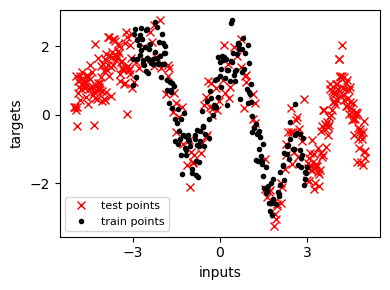

In [8]:
fig, ax = plt.subplots(figsize=[4, 3])
ax.plot(x_test, y_test, 'x', color='r', label='test points')
ax.plot(x_train, y_train, '.', color='k', label='train points')
ax.set_xlabel('inputs')
ax.set_ylabel('targets')
ax.set_xticks([-3, 0, 3])
ax.set_yticks([-2, 0, 2])
ax.legend(fontsize=8)
fig.tight_layout()
plt.show()

### Exact GP

Epoch 200/2000, Loss: 0.9800
Epoch 400/2000, Loss: 0.9317
Epoch 600/2000, Loss: 0.8914
Epoch 800/2000, Loss: 0.8585
Epoch 1000/2000, Loss: 0.8330
Epoch 1200/2000, Loss: 0.8149
Epoch 1400/2000, Loss: 0.8033
Epoch 1600/2000, Loss: 0.7966
Epoch 1800/2000, Loss: 0.7933
Epoch 2000/2000, Loss: 0.7917


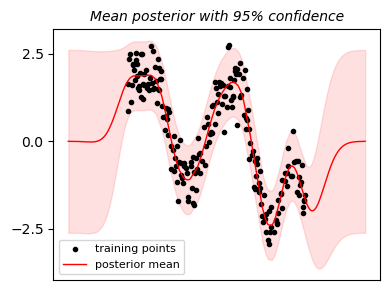

In [12]:
class ExactGPModel(gpytorch.models.ExactGP):
    def __init__(self, train_x, train_y, likelihood):
        super(ExactGPModel, self).__init__(train_x, train_y, likelihood)
        self.mean_module = gpytorch.means.ZeroMean()
        self.covar_module = gpytorch.kernels.ScaleKernel(gpytorch.kernels.RBFKernel())

    def forward(self, x):
        mean_x = self.mean_module(x)
        covar_x = self.covar_module(x)
        return gpytorch.distributions.MultivariateNormal(mean_x, covar_x)
    
# initialize likelihood and model
gp_likelihood = gpytorch.likelihoods.GaussianLikelihood()
gp_model = ExactGPModel(x_train, y_train, gp_likelihood)

gp_optimizer = torch.optim.AdamW(gp_model.parameters(), lr=0.001)
gp_criterion = gpytorch.mlls.ExactMarginalLogLikelihood(gp_likelihood, gp_model)

gp_model = gp_model.to(device)
gp_likelihood = gp_likelihood.to(device)

# Train the model
total_epochs = 2000
for epoch in range(total_epochs):
    gp_model.train()
    gp_likelihood.train()

    gp_optimizer.zero_grad()
    output = gp_model(x_train.to(device))
    loss = - gp_criterion(output, y_train.to(device))
    loss.backward()
    gp_optimizer.step()

    if (epoch + 1) % (total_epochs // 10) == 0:
        print(f'Epoch {epoch + 1}/{total_epochs}, Loss: {loss.item():.4f}')
        
# Evaluate the model
gp_model.eval()
gp_likelihood.eval()
with torch.no_grad(), gpytorch.settings.fast_pred_var():
    test_dist = gp_likelihood(gp_model(x_test.to(device)))
    mean = test_dist.mean.cpu().numpy()
    lower, upper = test_dist.confidence_region()
    lower = lower.cpu().numpy()
    upper = upper.cpu().numpy()
    
plot_confidence_region(y_train.cpu().numpy(), mean, lower, upper, fig_path='./plots/1D_gpr.pdf')

### DKL with Kernel Inducing Feature Factor

In [4]:
from csgp.layers.linear import LinearFlipout
from csgp.layers.activation import KernelInducingFeatures
from csgp.design_class import HyperbolicCrossDesign
from csgp.utils import ScaleToBounds

class KIFFGP(nn.Module):
    def __init__(self, in_features, out_features, dyadic_level, kernel, grid_bounds=(0., 1.),
                 prior_mean=0, prior_variance=1, posterior_mu_init=0, posterior_rho_init=-3.0,
                 bias=True, learn_inducing_locations=True, learn_kernel_hyperparams=True):
        super(KIFFGP, self).__init__()
        
        grid_points = HyperbolicCrossDesign(dyadic_sort=True, return_neighbors=True)(deg=dyadic_level,
                                                                                       input_lb=grid_bounds[0],
                                                                                       input_ub=grid_bounds[1]).points.reshape(-1, 1)  # [M, 1] size tensor
        
        # expand to [in_features, M, 1]
        grid_points = grid_points.unsqueeze(0).expand(in_features, -1, -1)
        
        in_dim = in_features * ((2 ** dyadic_level) - 1)
        
        self.kernel_features = KernelInducingFeatures(
            kernel=kernel, 
            inducing_points=grid_points, 
            learn_inducing_locations=learn_inducing_locations, 
            learn_kernel_hyperparams=learn_kernel_hyperparams,
        )

        self.linear = LinearFlipout(
            in_features=in_dim,
            out_features=out_features,
            prior_mean=prior_mean,
            prior_variance=prior_variance,
            posterior_mu_init=posterior_mu_init,
            posterior_rho_init=posterior_rho_init,
            bias=bias
        )

        # This module will scale the features so that they're nice values
        self.scale_to_bounds = ScaleToBounds(grid_bounds[0], grid_bounds[1])

    def forward(self, x, return_kl=False):
        x = self.scale_to_bounds(x).unsqueeze(-1)  # [batch_size, 1]
        phi_x = self.kernel_features(x).flatten(start_dim=-2)  # [batch_size, in_features * num_inducing_points]
        
        if return_kl:
            res, kl = self.linear(phi_x, return_kl=return_kl)
            return res, kl
        else:
            res = self.linear(phi_x, return_kl=return_kl)
            return res

    def mc_forward(self, x, num_mc=1, return_kl=False):
        x = self.scale_to_bounds(x).unsqueeze(-1)  # [batch_size, 1]
        phi_x = self.kernel_features(x).flatten(start_dim=-2)  # [batch_size, in_features * num_inducing_points]
        
        res_ = []
        kl_ = []
        for mc_run in range(num_mc):
            res, kl = self.linear(phi_x, return_kl=True)
            res_.append(res)
            kl_.append(kl)
        res = torch.stack(res_)  # (num_mc, batch_size, out_features)
        kl = torch.mean(torch.stack(kl_), dim=0)
        if return_kl:
            return res, kl
        else:
            return res

In [43]:
class FeatureExtractor(nn.Module):
    def __init__(self, in_features, num_features):
        super().__init__()
        self.fc1 = nn.Linear(in_features, 64)
        self.fc2 = nn.Linear(64, 64)
        self.fc3 = nn.Linear(64, num_features)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.fc3(x)


class DKL(nn.Module):
    def __init__(self, input_dim, output_dim, dyadic_level, kernel, learn_inducing_locations=True, learn_kernel_hyperparams=True):
        super(DKL, self).__init__()
        
        num_features = 4
        self.feature_extractor = FeatureExtractor(input_dim, num_features)
        self.gp = KIFFGP(
            in_features=num_features,
            out_features=output_dim,
            dyadic_level=dyadic_level,
            kernel=kernel,
            learn_inducing_locations=learn_inducing_locations,
            learn_kernel_hyperparams=learn_kernel_hyperparams
        )
        
    def forward(self, x, return_kl=True):
        x = self.feature_extractor(x)
        res, kl = self.gp(x, return_kl=True)
        if return_kl:
            return res, kl
        else:
            return res
        
    def forward_with_MC(self, x, num_mc=1, return_kl=True):
        x = self.feature_extractor(x)
        res, kl = self.gp.mc_forward(x, num_mc=num_mc, return_kl=True)
        if return_kl:
            return res, kl
        else:
            return res

Epoch [0/2000], Loss: 2.2623767852783203
Epoch [200/2000], Loss: 0.2548004686832428
Epoch [400/2000], Loss: 0.21985460817813873
Epoch [600/2000], Loss: 0.2029464691877365
Epoch [800/2000], Loss: 0.23447903990745544
Epoch [1000/2000], Loss: 0.22110211849212646
Epoch [1200/2000], Loss: 0.22868528962135315
Epoch [1400/2000], Loss: 0.20494626462459564
Epoch [1600/2000], Loss: 0.19630533456802368
Epoch [1800/2000], Loss: 0.1912192404270172


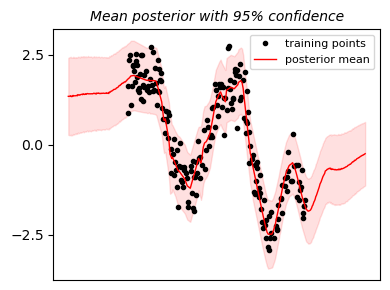

In [54]:
# Train DKL
def train_dkl(model, criterion, optimizer, num_mc=1, epochs=2000, device="cpu"):
    model = model.to(device)
    x_train_ = x_train.to(device)
    y_train_ = y_train.to(device)

    losses = []
    # bnn_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        output_, kl = model.forward_with_MC(x_train_, num_mc=num_mc, return_kl=True)
        output = torch.mean(output_, dim=0)
        loss = criterion(output, y_train_.view(-1,1)) + kl / len(x_train)

        loss.backward()
        optimizer.step()
        # bnn_scheduler.step()

        losses.append(loss.item())
        if epoch % 200 == 0:
            print(f'Epoch [{epoch}/{epochs}], Loss: {loss.item()}')

    return losses

def evaluate_dkl(model, num_mc=1000, device="cpu"):
    model = model.to(device)
    x_test_ = x_test.to(device)

    model.eval()
    with torch.no_grad():
        
        predicts = model.forward_with_MC(x_test_, num_mc=num_mc, return_kl=False)
        predicts = predicts.cpu().data.numpy()
        # predicts = []
        # for mc_run in range(num_mc):
        #     output = model(x_test_, return_kl=False)
        #     predicts.append(output.cpu().data.numpy())

        pred_mean = np.mean(predicts, axis=0)
        pred_std = np.std(predicts, axis=0)
        lower = pred_mean - 2 * pred_std
        upper = pred_mean + 2 * pred_std

    return pred_mean, lower.squeeze(), upper.squeeze()


kernel = gpytorch.kernels.ScaleKernel(gpytorch.kernels.MaternKernel(nu=1.5))

dkl_model = DKL(input_dim=1,
                output_dim=1,
                dyadic_level=6,
                kernel=kernel,
                learn_inducing_locations=True,
                learn_kernel_hyperparams=True,
                )

dkl_losses = train_dkl(
    model=dkl_model,
    criterion=nn.MSELoss(),
    optimizer=torch.optim.AdamW(dkl_model.parameters(), lr=0.005, weight_decay=0.0001),
    num_mc=10,
    epochs=2000
)

dkl_mean, dkl_lower, dkl_upper = evaluate_dkl(dkl_model, num_mc=5000)
plot_confidence_region(y_train, dkl_mean, dkl_lower, dkl_upper, fig_path='./plots/1D_dkl.pdf')